<a href="https://colab.research.google.com/github/dhanesh0369/ML/blob/main/data_viz_AP23110010275_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#import libraries
import pandas as pd
import seaborn as sns

In [2]:
#set kaggle API credentials
import os
os.environ['KAGGLE_USERNAME'] = 'ap23110010275'
os.environ['KAGGLE_KEY'] = '27405ff49dac5826fa0cccd271a1cf70'


In [3]:
#download dataset
!kaggle datasets download -d uciml/breast-cancer-wisconsin-data

Dataset URL: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data
License(s): CC-BY-NC-SA-4.0
  0% 0.00/48.6k [00:00<?, ?B/s]
100% 48.6k/48.6k [00:00<00:00, 123MB/s]


In [4]:
#unzip file
!unzip breast-cancer-wisconsin-data.zip

Archive:  breast-cancer-wisconsin-data.zip
  inflating: data.csv                


In [5]:
#load data on dataframe
df = pd.read_csv('/content/data.csv')

In [6]:
#display dataframe
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


# Task
Load the dataset "breast_cancer.csv" into a pandas DataFrame and perform the following bivariate data visualizations: Continuous-Continuous (Scatter plot with styling and labelling), Categorical-Categorical (Dodged and Stacked countplots), and Categorical-Continuous (Boxplot and Bar plot with mean estimator). Finally, organize a selection of these plots into subplots. Interpret the results of each visualization in the context of the dataset.

## Inspect data

### Subtask:
Use `.head()` and `.describe()` to examine the structure and summary statistics of the breast cancer dataset (`df`), as you described in the first part of your instructions.


**Reasoning**:
Display the first 5 rows of the DataFrame and generate descriptive statistics for the numerical columns.



In [7]:
display(df.head())
display(df.describe())

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


## Identify variables for visualization

### Subtask:
Identify suitable continuous and categorical columns from the breast cancer dataset for the bivariate visualizations you described (Continuous-Continuous, Categorical-Categorical, Categorical-Continuous).


**Reasoning**:
Identify continuous and categorical columns by examining the dataframe columns and types.



In [8]:
print(df.columns)
print(df.info())

continuous_cols = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
                   'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se',
                   'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']
categorical_cols = ['diagnosis']

print("\nIdentified Continuous Columns:", continuous_cols)
print("\nIdentified Categorical Columns:", categorical_cols)

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_me

## Continuous-continuous visualization

### Subtask:
Generate scatter plots (as line plots are less applicable without a time variable) for selected pairs of continuous variables, incorporating styling and labeling as you outlined.


**Reasoning**:
Generate a scatter plot for two continuous variables and add labels and a title.



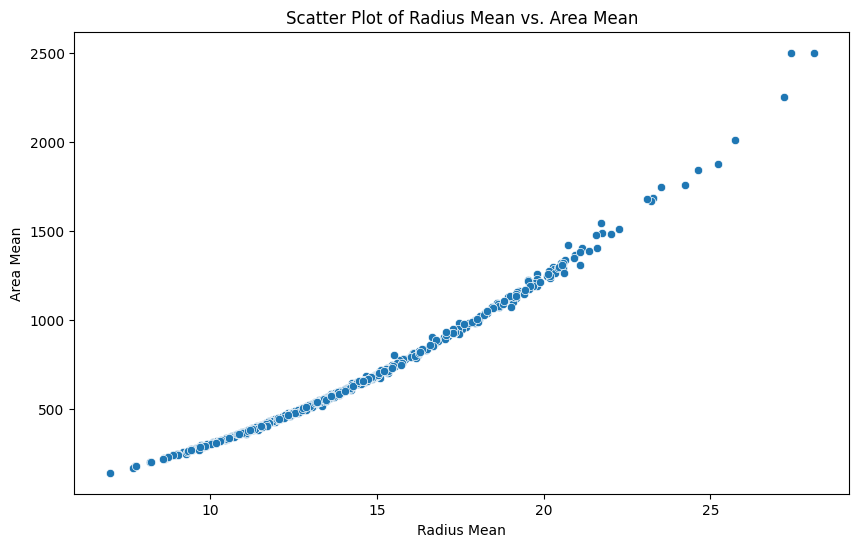

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.scatterplot(x='radius_mean', y='area_mean', data=df)
plt.xlabel('Radius Mean')
plt.ylabel('Area Mean')
plt.title('Scatter Plot of Radius Mean vs. Area Mean')
plt.show()

**Reasoning**:
The previous scatter plot was generated successfully. The next step is to generate another scatter plot for a different pair of continuous variables to further visualize the relationships between them.



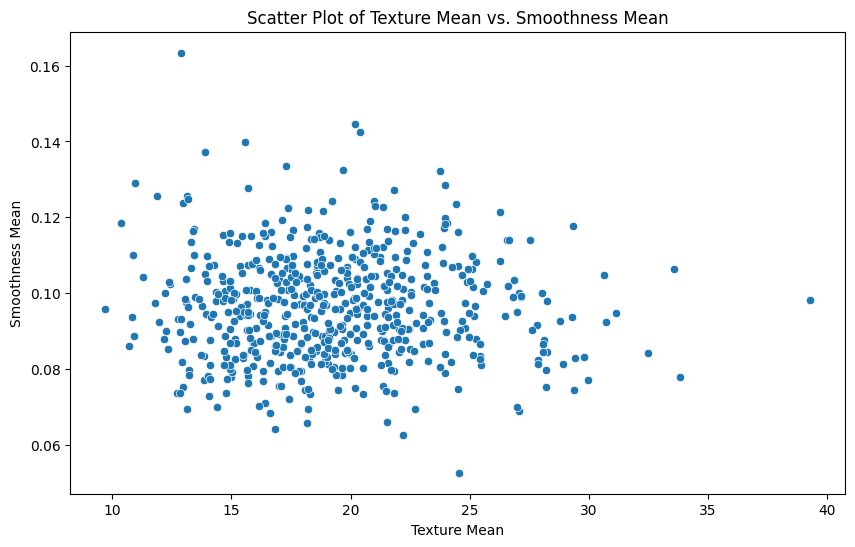

In [10]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='texture_mean', y='smoothness_mean', data=df)
plt.xlabel('Texture Mean')
plt.ylabel('Smoothness Mean')
plt.title('Scatter Plot of Texture Mean vs. Smoothness Mean')
plt.show()

## Categorical-categorical visualization

### Subtask:
Generate dodged and stacked countplots for relevant pairs of categorical variables (e.g., using the 'diagnosis' column and potentially creating a new categorical feature if needed), applying the techniques you described (using `seaborn.countplot` and `pandas.crosstab`).


**Reasoning**:
Calculate the counts of each unique value in the 'diagnosis' column and store it in a variable for the countplots.



In [11]:
diagnosis_counts = df['diagnosis'].value_counts()
print(diagnosis_counts)

diagnosis
B    357
M    212
Name: count, dtype: int64


**Reasoning**:
Create a dodged countplot of the 'diagnosis' column using seaborn.countplot, adding a title and appropriate axis labels.



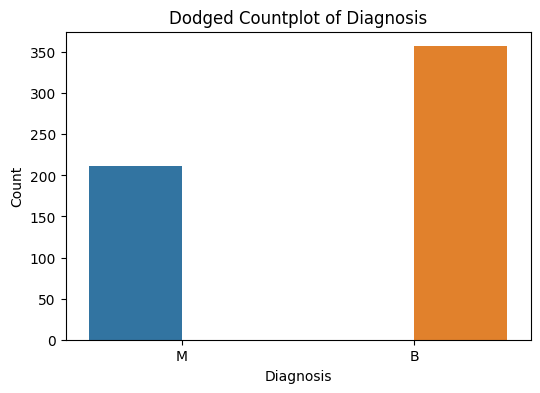

In [12]:
plt.figure(figsize=(6, 4))
sns.countplot(x='diagnosis', data=df, hue='diagnosis', dodge=True)
plt.title('Dodged Countplot of Diagnosis')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.show()

**Reasoning**:
Create a stacked countplot of the 'diagnosis' column using seaborn.countplot, adding a title and appropriate axis labels.



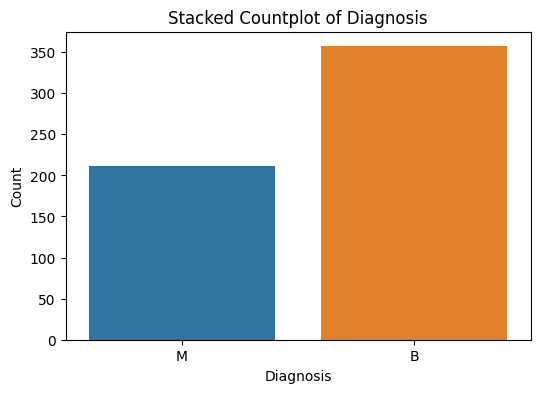

In [13]:
plt.figure(figsize=(6, 4))
sns.countplot(x='diagnosis', data=df, hue='diagnosis', dodge=False)
plt.title('Stacked Countplot of Diagnosis')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.show()

## Categorical-continuous visualization

### Subtask:
Generate boxplots and bar plots with a mean estimator for selected continuous variables against the 'diagnosis' categorical variable, using the methods you detailed (using `seaborn.boxplot` and `seaborn.barplot` with `estimator=np.mean`).


**Reasoning**:
Import the numpy library and then create the boxplots and bar plots for the selected continuous variables against the 'diagnosis' variable as requested, including titles and labels.



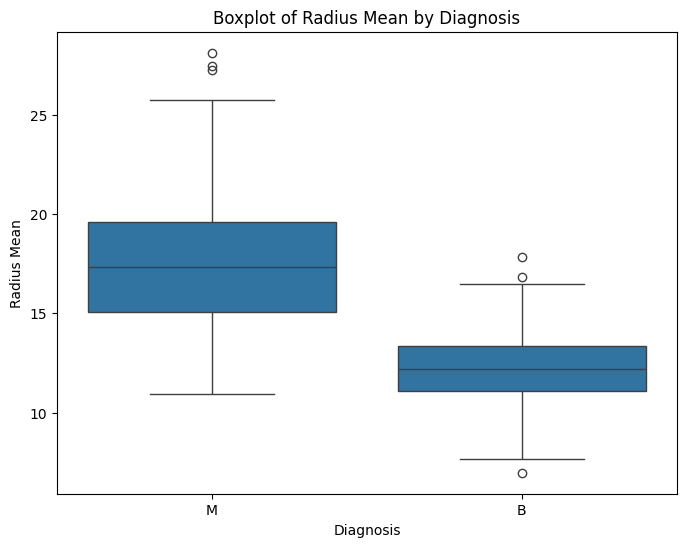

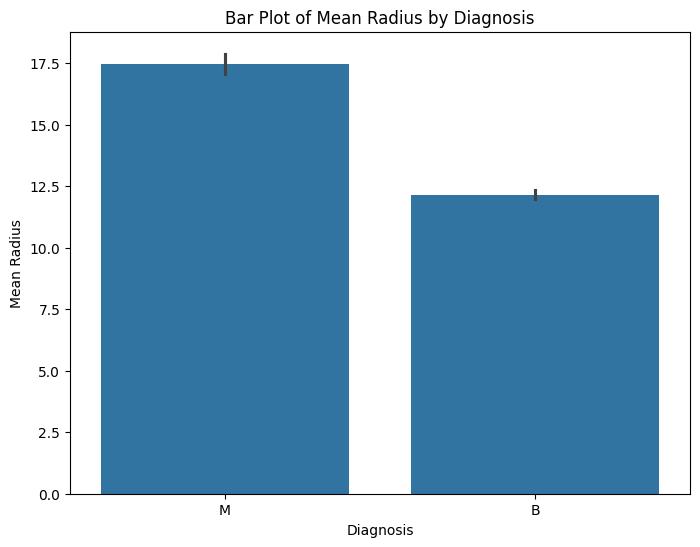

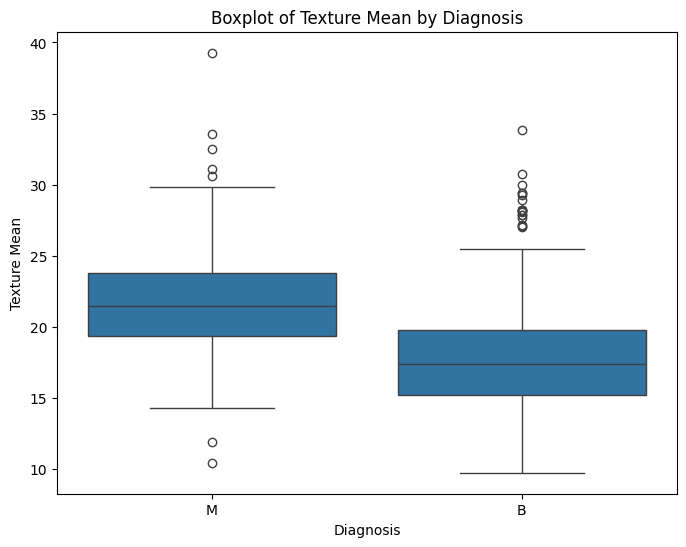

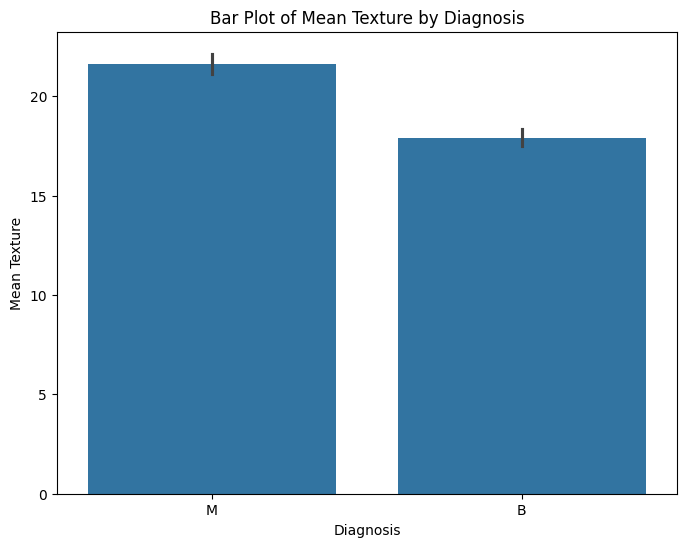

In [14]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.boxplot(x='diagnosis', y='radius_mean', data=df)
plt.title('Boxplot of Radius Mean by Diagnosis')
plt.xlabel('Diagnosis')
plt.ylabel('Radius Mean')
plt.show()

plt.figure(figsize=(8, 6))
sns.barplot(x='diagnosis', y='radius_mean', data=df, estimator=np.mean)
plt.title('Bar Plot of Mean Radius by Diagnosis')
plt.xlabel('Diagnosis')
plt.ylabel('Mean Radius')
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(x='diagnosis', y='texture_mean', data=df)
plt.title('Boxplot of Texture Mean by Diagnosis')
plt.xlabel('Diagnosis')
plt.ylabel('Texture Mean')
plt.show()

plt.figure(figsize=(8, 6))
sns.barplot(x='diagnosis', y='texture_mean', data=df, estimator=np.mean)
plt.title('Bar Plot of Mean Texture by Diagnosis')
plt.xlabel('Diagnosis')
plt.ylabel('Mean Texture')
plt.show()

## Create subplots

### Subtask:
Organize a selection of the generated plots into subplots using either `plt.subplots()` or `plt.subplot()`, adding a main title and individual subplot titles and labels as you described, and using `plt.tight_layout()`.


**Reasoning**:
Organize a selection of the generated plots into subplots using `plt.subplots()`, adding a main title and individual subplot titles and labels, and using `plt.tight_layout()`.



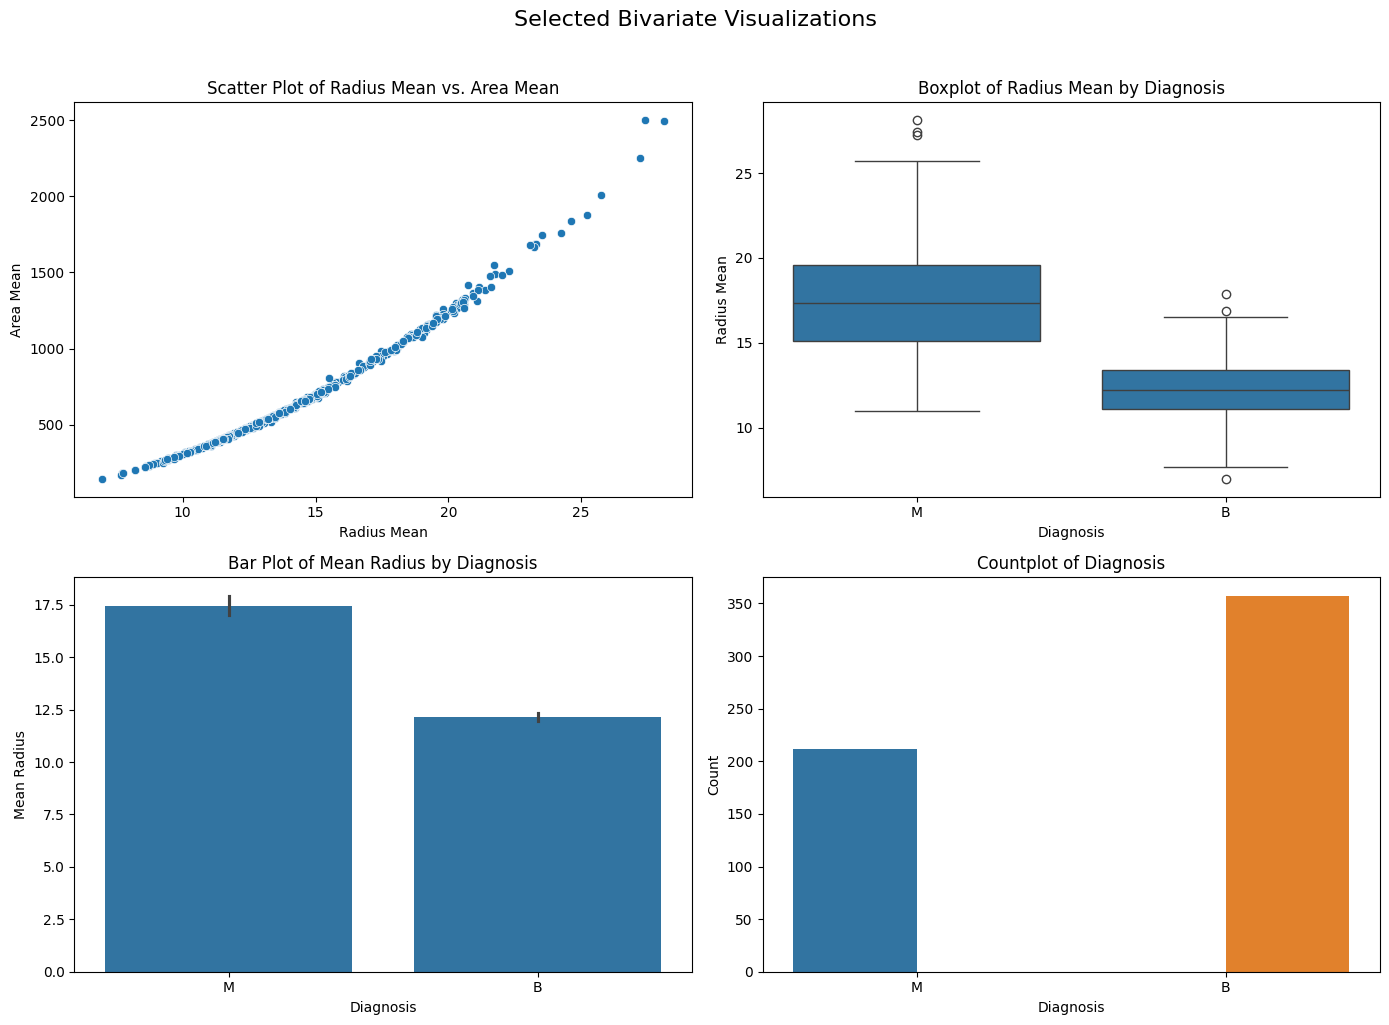

In [18]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

# Scatter plot of Radius Mean vs. Area Mean
sns.scatterplot(x='radius_mean', y='area_mean', data=df, ax=axes[0, 0])
axes[0, 0].set_title('Scatter Plot of Radius Mean vs. Area Mean')
axes[0, 0].set_xlabel('Radius Mean')
axes[0, 0].set_ylabel('Area Mean')

# Boxplot of Radius Mean by Diagnosis
sns.boxplot(x='diagnosis', y='radius_mean', data=df, ax=axes[0, 1])
axes[0, 1].set_title('Boxplot of Radius Mean by Diagnosis')
axes[0, 1].set_xlabel('Diagnosis')
axes[0, 1].set_ylabel('Radius Mean')

# Bar Plot of Mean Radius by Diagnosis
sns.barplot(x='diagnosis', y='radius_mean', data=df, estimator=np.mean, ax=axes[1, 0])
axes[1, 0].set_title('Bar Plot of Mean Radius by Diagnosis')
axes[1, 0].set_xlabel('Diagnosis')
axes[1, 0].set_ylabel('Mean Radius')

# Dodged Countplot of Diagnosis
sns.countplot(x='diagnosis', data=df, hue='diagnosis', dodge=True, ax=axes[1, 1])
axes[1, 1].set_title('Countplot of Diagnosis')
axes[1, 1].set_xlabel('Diagnosis')
axes[1, 1].set_ylabel('Count')


plt.suptitle('Selected Bivariate Visualizations', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

**Reasoning**:
The previous attempt to remove the legend failed because `get_legend()` returned `None`. This happens when `hue` is used with `countplot` but the legend is not explicitly created or is handled differently by the plotting function within the subplot context. I will remove the line that attempts to remove the legend and regenerate the plots within subplots.



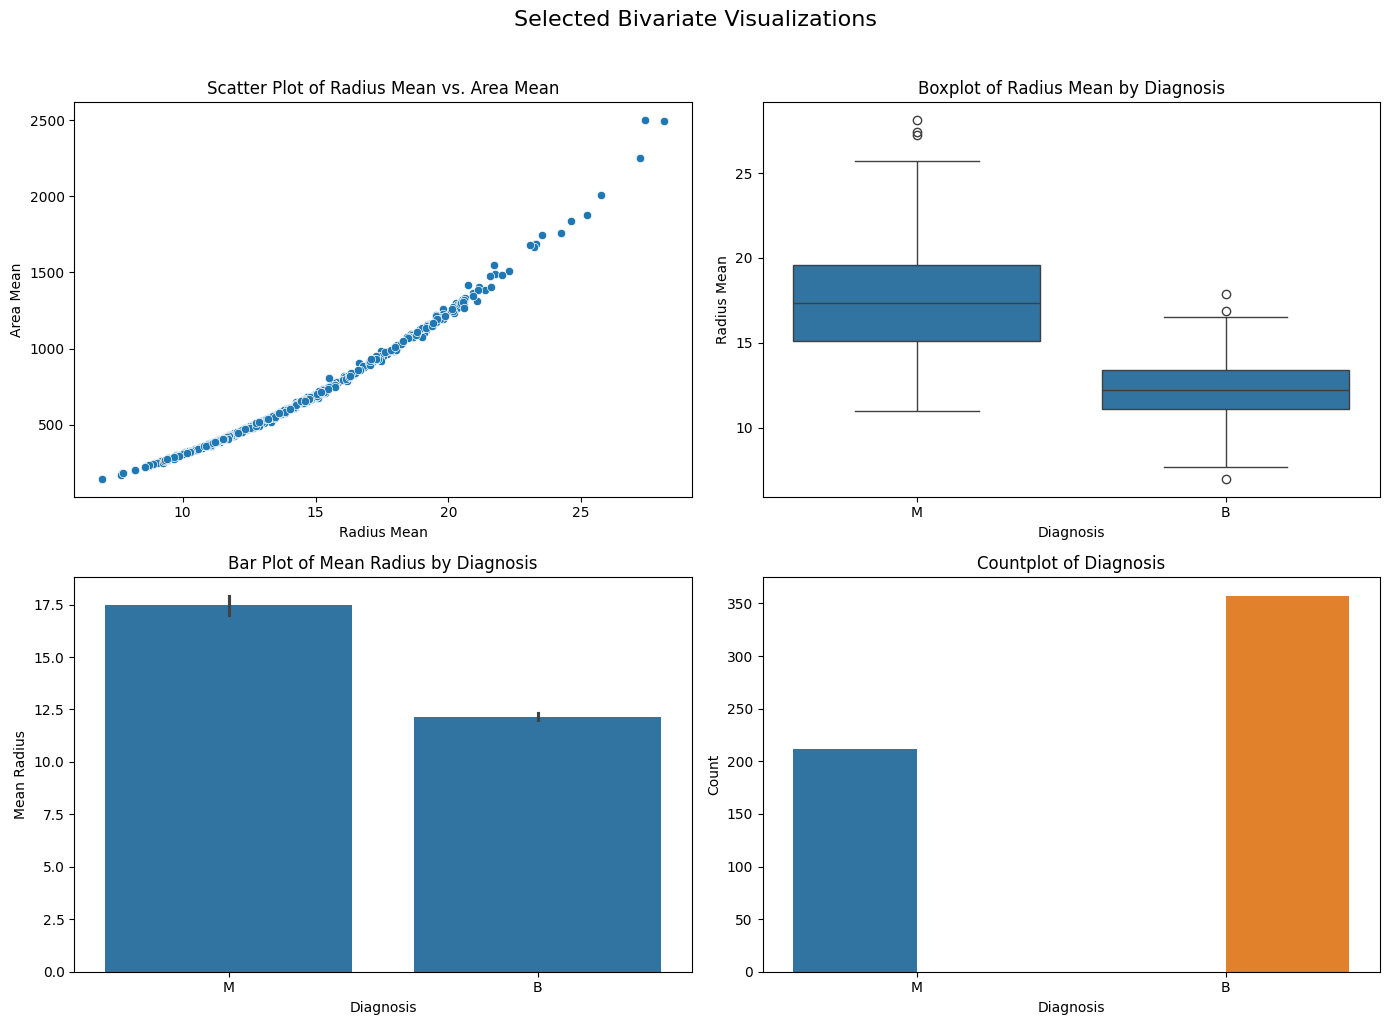

In [17]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

# Scatter plot of Radius Mean vs. Area Mean
sns.scatterplot(x='radius_mean', y='area_mean', data=df, ax=axes[0, 0])
axes[0, 0].set_title('Scatter Plot of Radius Mean vs. Area Mean')
axes[0, 0].set_xlabel('Radius Mean')
axes[0, 0].set_ylabel('Area Mean')

# Boxplot of Radius Mean by Diagnosis
sns.boxplot(x='diagnosis', y='radius_mean', data=df, ax=axes[0, 1])
axes[0, 1].set_title('Boxplot of Radius Mean by Diagnosis')
axes[0, 1].set_xlabel('Diagnosis')
axes[0, 1].set_ylabel('Radius Mean')

# Bar Plot of Mean Radius by Diagnosis
sns.barplot(x='diagnosis', y='radius_mean', data=df, estimator=np.mean, ax=axes[1, 0])
axes[1, 0].set_title('Bar Plot of Mean Radius by Diagnosis')
axes[1, 0].set_xlabel('Diagnosis')
axes[1, 0].set_ylabel('Mean Radius')

# Dodged Countplot of Diagnosis
sns.countplot(x='diagnosis', data=df, hue='diagnosis', dodge=True, ax=axes[1, 1])
axes[1, 1].set_title('Countplot of Diagnosis')
axes[1, 1].set_xlabel('Diagnosis')
axes[1, 1].set_ylabel('Count')


plt.suptitle('Selected Bivariate Visualizations', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

## Interpret results

### Subtask:
Explain the insights gained from each type of bivariate visualization in the context of the breast cancer dataset.


**Reasoning**:
Analyze each visualization and describe the insights gained from each plot in the context of the breast cancer dataset based on the instructions.



In [19]:
print("Analysis of Scatter Plot (Radius Mean vs. Area Mean):")
print("The scatter plot shows a strong positive correlation between 'radius_mean' and 'area_mean'. As the mean radius of a tumor increases, its area tends to increase significantly. This is expected as area is proportional to the square of the radius (or a similar dimension for irregular shapes). The spread of data points suggests that while there's a clear relationship, there's also some variability, potentially due to other factors influencing the tumor's shape.")

print("\nAnalysis of Boxplot and Bar Plot (Radius Mean by Diagnosis):")
print("Both the boxplot and the bar plot clearly show that tumors diagnosed as Malignant ('M') have a significantly larger 'radius_mean' compared to tumors diagnosed as Benign ('B'). The boxplot shows that the median and the interquartile range for malignant tumors are much higher. The bar plot reinforces this by showing a substantially higher mean 'radius_mean' for malignant cases. This indicates that 'radius_mean' is a strong distinguishing feature between benign and malignant breast cancer cases.")

print("\nAnalysis of Countplot (Diagnosis):")
print("The countplot shows the distribution of diagnoses in the dataset. There are more instances of Benign ('B') diagnoses compared to Malignant ('M') diagnoses. Specifically, there are 357 benign cases and 212 malignant cases. This indicates that the dataset is imbalanced, with a higher representation of benign tumors.")

print("\nDiscussion on the potential of these features for differentiation:")
print("Based on the visualizations:")
print("- 'radius_mean' and 'area_mean' are highly correlated. 'radius_mean' (and likely 'area_mean' due to the correlation) shows a clear difference in distribution and mean between benign and malignant tumors. This suggests that 'radius_mean' is a powerful feature for differentiating the two classes.")
print("- The 'diagnosis' countplot reveals the class distribution, highlighting the imbalance in the dataset. While not a feature for differentiation itself in this context, understanding this distribution is crucial for model training and evaluation.")
print("Overall, 'radius_mean' appears to be a key feature for distinguishing between benign and malignant breast cancer cases. The strong correlation between 'radius_mean' and 'area_mean' suggests that both might capture similar information, although further analysis would be needed to confirm if both are necessary for a predictive model. The diagnosis distribution provides essential context about the dataset.")

Analysis of Scatter Plot (Radius Mean vs. Area Mean):
The scatter plot shows a strong positive correlation between 'radius_mean' and 'area_mean'. As the mean radius of a tumor increases, its area tends to increase significantly. This is expected as area is proportional to the square of the radius (or a similar dimension for irregular shapes). The spread of data points suggests that while there's a clear relationship, there's also some variability, potentially due to other factors influencing the tumor's shape.

Analysis of Boxplot and Bar Plot (Radius Mean by Diagnosis):
Both the boxplot and the bar plot clearly show that tumors diagnosed as Malignant ('M') have a significantly larger 'radius_mean' compared to tumors diagnosed as Benign ('B'). The boxplot shows that the median and the interquartile range for malignant tumors are much higher. The bar plot reinforces this by showing a substantially higher mean 'radius_mean' for malignant cases. This indicates that 'radius_mean' is a stro

## Summary:

### Data Analysis Key Findings

*   The dataset contains 33 columns, including numerical features related to tumor characteristics and a categorical 'diagnosis' column ('M' for malignant, 'B' for benign).
*   There is a strong positive correlation between 'radius\_mean' and 'area\_mean', indicating that as the mean radius of a tumor increases, its area tends to increase significantly.
*   Tumors diagnosed as Malignant ('M') have a significantly larger 'radius\_mean' compared to tumors diagnosed as Benign ('B'), making 'radius\_mean' a strong distinguishing feature.
*   The dataset is imbalanced, with 357 benign cases and 212 malignant cases.

### Insights or Next Steps

*   Given the strong correlation between 'radius\_mean' and 'area\_mean' and their clear difference between benign and malignant cases, these features are likely important for building a predictive model.
*   The class imbalance in the 'diagnosis' column should be considered when building and evaluating classification models to avoid bias towards the majority class. Techniques like oversampling, undersampling, or using appropriate evaluation metrics (e.g., precision, recall, F1-score) may be necessary.
